--- Importing Libraries ---
Torch version: 2.6.0+cu118
Torchvision version: 0.21.0+cu118
Using device: cuda
Spectrogram Size (Target): (224, 224)
Saving results and BEST model to: ./rerun_trial_843_best_only/

--- Using Fixed Hyperparameters from Trial 843 ---
  lr: 0.0001427629680371007
  dropout_p: 0.30000000000000004
  weight_decay: 0.0007606531254645368
  specaug_freq: 10
  specaug_time: 20
  specaug_f_masks: 3
  specaug_t_masks: 1

--- Defining Helper Functions ---

--- Loading Original and New Data ---
Loading data (Signal Aug: False, Prob: 0.5)...
Finished loading. Processed 3 files. Total spectrograms created: 143
Loading data (Signal Aug: False, Prob: 0.5)...
  Processed 50/354 files...
  Processed 100/354 files...
  Processed 150/354 files...
  Processed 200/354 files...
  Processed 250/354 files...
  Processed 300/354 files...
  Processed 350/354 files...
Finished loading. Processed 354 files. Total spectrograms created: 6018
Original Spectrogram data shape: (143, 3, 224, 22

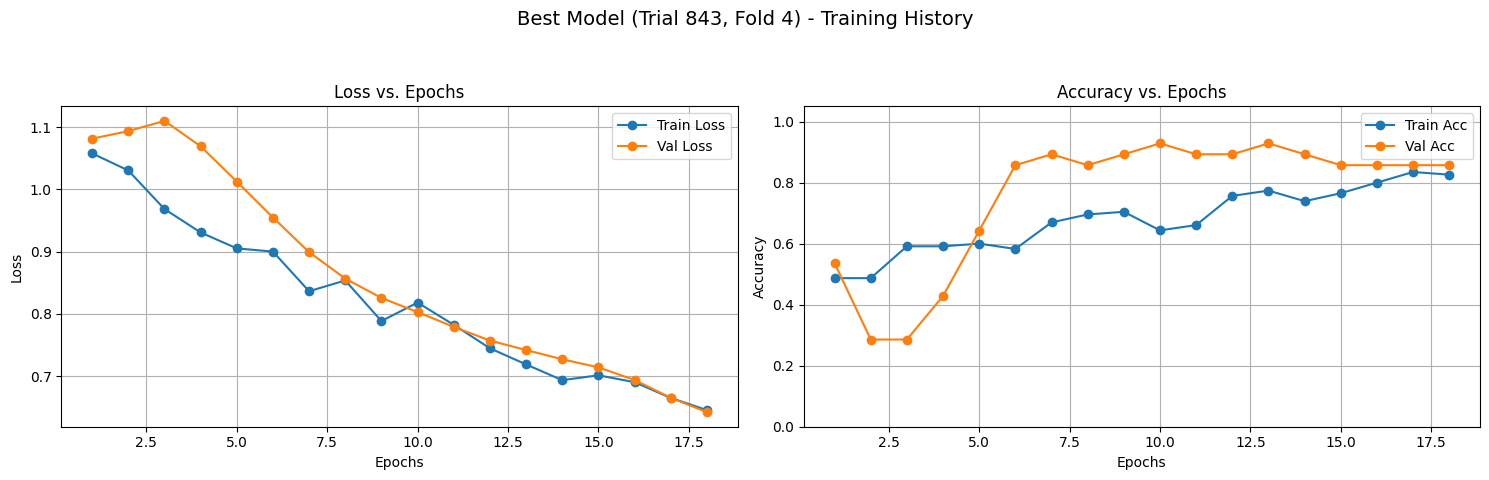


Validation Set Performance (Original Data):
Confusion Matrix (Validation):
[[13  0  0]
 [ 0  6  0]
 [ 2  0  7]]

Classification Report (Validation):
              precision    recall  f1-score   support

       Steps       0.87      1.00      0.93        13
     Vehicle       1.00      1.00      1.00         6
       Noise       1.00      0.78      0.88         9

    accuracy                           0.93        28
   macro avg       0.96      0.93      0.93        28
weighted avg       0.94      0.93      0.93        28

Saved validation CM plot: ./rerun_trial_843_best_only/BEST_MODEL_trial_843_4_cm_validation.png


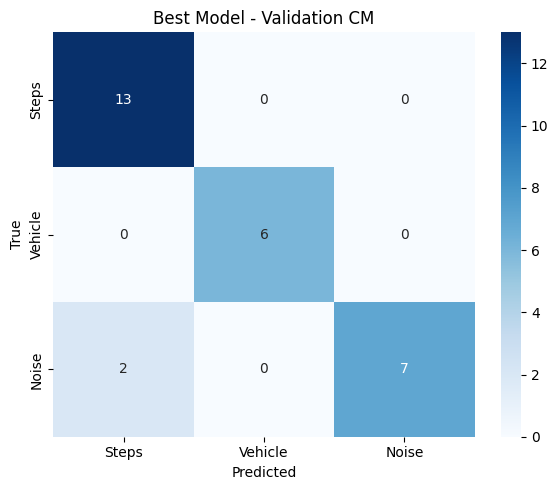


New Dataset Performance (Normalized Data):
Overall Accuracy (New Data): 0.8948
'Steps' Recall (New Data): 0.8948

Confusion Matrix (New Data):
[[5385  310  323]
 [   0    0    0]
 [   0    0    0]]

Classification Report (New Data):
              precision    recall  f1-score   support

       Steps       1.00      0.89      0.94      6018
     Vehicle       0.00      0.00      0.00         0
       Noise       0.00      0.00      0.00         0

    accuracy                           0.89      6018
   macro avg       0.33      0.30      0.31      6018
weighted avg       1.00      0.89      0.94      6018

Saved new data CM plot: ./rerun_trial_843_best_only/BEST_MODEL_trial_843_4_cm_new_data.png


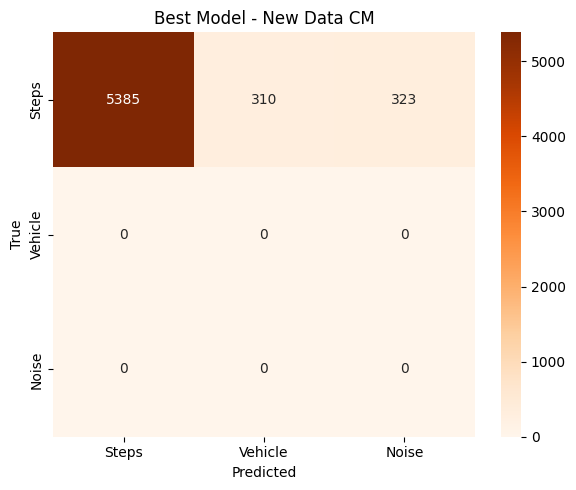


--- Re-run and Analysis Script Finished ---


In [2]:
# ==============================================================================
# === קוד להרצה מחדש, ניתוח ושמירת המודל הבודד הטוב ביותר מ-Trial 843 ===
# === (EfficientNet, ספקטרוגרמות) ===
# ==============================================================================

# --- 1. ייבוא והגדרות (זהה לקוד הקודם) ---
print("--- Importing Libraries ---")
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, classification_report
from scipy.signal import butter, filtfilt, spectrogram
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import random
from copy import deepcopy
import cv2
import warnings
import torchvision

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- הגדרות גלובליות (זהות לקוד הקודם) ---
LABEL_MAN = 0; LABEL_CAR = 1; LABEL_NOISE = 2
CLASS_NAMES = ["Steps", "Vehicle", "Noise"]; NUM_CLASSES = 3
window_size = 2000; stride = 500; fs = 1000.0; max_channels = 39
N_MELS = 128; N_FFT = 1024; HOP_LENGTH = window_size // (N_MELS * 2) # ~8
IMG_WIDTH = int(np.floor(window_size / HOP_LENGTH) + 1) # ~251
IMG_HEIGHT_FINAL = 224; IMG_WIDTH_FINAL = 224
lowcut = 1.0; highcut = 100.0; order = 4
print(f"Spectrogram Size (Target): ({IMG_HEIGHT_FINAL}, {IMG_WIDTH_FINAL})")

# הגדרות K-Fold ואימון (ערכים קבועים)
N_SPLITS = 5; EPOCHS = 50; PATIENCE = 8; BATCH_SIZE = 32
MODEL_NAME = 'efficientnet_b0'

# ספי דיוק לולידציה
MIN_VAL_ACC_THRESHOLD = 0.70
MAX_VAL_ACC_THRESHOLD = 0.995 # חשוב למניעת שמירת מודלים עם 100%

# נתיבים (זהה לקוד הקודם)
ORIGINAL_DATA_PATHS = {
    LABEL_MAN: {'path': 'man.csv'},
    LABEL_CAR: {'path': 'car.csv', 'args': {'skiprows': 1}},
    LABEL_NOISE: {'path': 'nothing.csv'}
}
NEW_DATA_FOLDER = 'newDataSET_csv'
# <<< שנה את שם קובץ השמירה לשם ברור עבור ההרצה הספציפית הזו >>>
SAVE_PATH_BASE = "./rerun_trial_843_best_only/" # תיקייה לשמירת התוצאות של ההרצה הזו
BEST_MODEL_FILENAME = os.path.join(SAVE_PATH_BASE, f"BEST_MODEL_trial_843_effnet.pth") # שם ברור למודל הטוב ביותר
os.makedirs(SAVE_PATH_BASE, exist_ok=True)
print(f"Saving results and BEST model to: {SAVE_PATH_BASE}")

# --- הגדרת ההיפרפרמטרים הספציפיים מ-Trial 843 ---
TRIAL_843_PARAMS = {
    'lr': 0.0001427629680371007,
    'dropout_p': 0.30000000000000004,
    'weight_decay': 0.0007606531254645368,
    'specaug_freq': 10,
    'specaug_time': 20,
    'specaug_f_masks': 3,
    'specaug_t_masks': 1
}
TRIAL_NUMBER = 843 # חשוב ל-random_state של KFold
print("\n--- Using Fixed Hyperparameters from Trial 843 ---")
for key, value in TRIAL_843_PARAMS.items():
    print(f"  {key}: {value}")

# --- 2. פונקציות עזר ועיבוד נתונים (זהות לקוד הקודם) ---
print("\n--- Defining Helper Functions ---")
# ... העתק לכאן את כל פונקציות העזר מהקוד הקודם ...
# pad_channels, create_windows, add_gaussian_noise_signal, time_stretch_signal,
# create_mel_spectrogram, load_data_specs_maybe_aug
def pad_channels(data, target_channels):
    if data.ndim == 1: data = data.reshape(-1, 1)
    if data.shape[1] == target_channels: return data
    elif data.shape[1] < target_channels:
        padding = np.zeros((data.shape[0], target_channels - data.shape[1]), dtype=data.dtype)
        return np.hstack((data, padding))
    else: return data[:, :target_channels]

def create_windows(signal, label, window_size=window_size, stride=stride):
    X_windows, y_labels = [], []
    if signal.shape[0] < window_size: return [], []
    for start in range(0, signal.shape[0] - window_size + 1, stride):
        X_windows.append(signal[start : start + window_size, :])
        y_labels.append(label)
    return X_windows, y_labels

def add_gaussian_noise_signal(signal_1d, noise_level=0.01):
    noise = np.random.normal(0, noise_level, signal_1d.shape)
    return signal_1d + noise

def time_stretch_signal(signal_1d, stretch_rate=1.0, target_len=window_size):
    try:
        stretched = librosa.effects.time_stretch(signal_1d.astype(np.float32), rate=stretch_rate)
        current_len = len(stretched)
        if current_len == target_len: return stretched
        elif current_len > target_len:
            start = random.randint(0, current_len - target_len)
            return stretched[start : start + target_len]
        else:
            pad_len = target_len - current_len
            pad_start = random.randint(0, pad_len)
            padded = np.zeros(target_len, dtype=np.float32)
            padded[pad_start : pad_start + current_len] = stretched
            return padded
    except Exception:
        if len(signal_1d) == target_len: return signal_1d.astype(np.float32)
        elif len(signal_1d) > target_len: return signal_1d[:target_len].astype(np.float32)
        else:
            padded = np.zeros(target_len, dtype=np.float32)
            padded[:len(signal_1d)] = signal_1d
            return padded

def create_mel_spectrogram(window_1d, sr=int(fs), n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS):
    try:
        signal = window_1d.astype(np.float32)
        if np.all(signal == signal[0]): return np.zeros((n_mels, IMG_WIDTH), dtype=np.float32)
        mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmin=1.0, fmax=min(highcut*1.2, sr/2 - 1))
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        min_db, max_db = mel_spec_db.min(), mel_spec_db.max()
        if max_db <= min_db: return np.zeros((n_mels, IMG_WIDTH), dtype=np.float32)
        mel_spec_norm = (mel_spec_db - min_db) / (max_db - min_db)
        expected_width = int(np.floor(len(signal) / hop_length) + 1)
        current_width = mel_spec_norm.shape[1]
        if current_width < expected_width:
             pad_width = expected_width - current_width
             mel_spec_norm = np.pad(mel_spec_norm, ((0,0), (0, pad_width)), mode='constant')
        elif current_width > expected_width:
             mel_spec_norm = mel_spec_norm[:, :expected_width]
        if not np.isfinite(mel_spec_norm).all(): return np.zeros((n_mels, IMG_WIDTH), dtype=np.float32)
        return mel_spec_norm.astype(np.float32)
    except Exception: return np.zeros((n_mels, IMG_WIDTH), dtype=np.float32)

def load_data_specs_maybe_aug(file_map, apply_signal_aug=False, signal_aug_prob=0.5, target_img_size=(IMG_HEIGHT_FINAL, IMG_WIDTH_FINAL)):
    all_specs, all_labels = [], []
    try: b, a = butter(order, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
    except ValueError as e: print(f"CRITICAL FILTER ERROR: {e}. Aborting."); return [], []
    print(f"Loading data (Signal Aug: {apply_signal_aug}, Prob: {signal_aug_prob})...")
    file_count = 0; specs_created_count = 0; processed_files = 0
    for label, info in file_map.items():
        filepaths = info.get('path', [])
        extra_args = info.get('args', {})
        if isinstance(filepaths, str): filepaths = [filepaths]
        if not filepaths: continue
        file_count += len(filepaths)
        for filepath in filepaths:
            processed_files += 1
            if not os.path.exists(filepath): print(f"Warning: File not found: {filepath}. Skipping."); continue
            try:
                try: df = pd.read_csv(filepath, header=None, skipinitialspace=True, **extra_args)
                except pd.errors.EmptyDataError: print(f"Warning: Empty file: {filepath}. Skipping."); continue
                except Exception: df = pd.read_csv(filepath, header=None, skiprows=1, skipinitialspace=True, **extra_args)
                df = df.dropna()
                if df.empty: continue
                data = df.values
                if not np.issubdtype(data.dtype, np.number): data = data.astype(float)
                if data.shape[0] < window_size or data.ndim < 2 or data.shape[1] == 0: continue
                data_padded = pad_channels(data, max_channels)
                windows, labels_w = create_windows(data_padded, label)
                if not windows: continue
                for i, w in enumerate(windows):
                    try:
                        filtered_w = filtfilt(b, a, w, axis=0)
                        signal_to_process = filtered_w[:, 0]
                        if apply_signal_aug and random.random() < signal_aug_prob:
                            aug_type = random.choice(['stretch', 'noise'])
                            if aug_type == 'stretch': signal_to_process = time_stretch_signal(signal_to_process, np.random.uniform(0.9, 1.1))
                            elif aug_type == 'noise': signal_to_process = add_gaussian_noise_signal(signal_to_process, np.random.uniform(0.005, 0.015))
                        mel_spec_norm = create_mel_spectrogram(signal_to_process)
                        if mel_spec_norm is None or mel_spec_norm.shape[0] != N_MELS or mel_spec_norm.shape[1] < 10: continue
                        resized_spec = cv2.resize(mel_spec_norm, (target_img_size[1], target_img_size[0]), interpolation=cv2.INTER_LINEAR)
                        spec_3_channels = np.stack([resized_spec]*3, axis=0)
                        if not np.isfinite(spec_3_channels).all(): continue
                        all_specs.append(spec_3_channels)
                        all_labels.append(labels_w[i])
                        specs_created_count += 1
                    except Exception: pass
            except Exception as e_file: print(f"Warning: Error processing file {filepath}: {e_file}")
            if processed_files % 50 == 0: print(f"  Processed {processed_files}/{file_count} files...")
    print(f"Finished loading. Processed {processed_files} files. Total spectrograms created: {specs_created_count}")
    if not all_specs: return np.array([]), np.array([], dtype=np.int64)
    return np.array(all_specs, dtype=np.float32), np.array(all_labels, dtype=np.int64)

# --- 3. טעינת הנתונים (זהה לקוד הקודם) ---
print("\n--- Loading Original and New Data ---")
all_original_specs_np, all_original_labels_np = load_data_specs_maybe_aug(ORIGINAL_DATA_PATHS, apply_signal_aug=False)
new_files = glob.glob(os.path.join(NEW_DATA_FOLDER, '*.csv')); new_file_map = {}
if new_files: new_file_map[LABEL_MAN] = {'path': new_files}
new_specs_np, new_labels_np = load_data_specs_maybe_aug(new_file_map, apply_signal_aug=False) if new_files else (np.array([]), np.array([]))
if all_original_specs_np.size == 0: print("CRITICAL ERROR: Failed to load original data."); exit()
print("Original Spectrogram data shape:", all_original_specs_np.shape)
if new_specs_np.size > 0: print("New Spectrogram data shape:", new_specs_np.shape)

# --- 4. הגדרות טרנספורמציות, Dataset, מודל, פונקציות (זהה לקודם) ---
print("\n--- Defining Transforms, Dataset, Model, Train/Eval Functions, Plotting ---")
imagenet_mean = [0.485, 0.456, 0.406]; imagenet_std = [0.229, 0.224, 0.225]

class SpecAugment(nn.Module): # הגדרה זהה לקודם
    def __init__(self, freq_mask_param=20, time_mask_param=40, num_freq_masks=1, num_time_masks=1):
        super().__init__(); self.freq_mask_param = freq_mask_param; self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks; self.num_time_masks = num_time_masks
    def forward(self, spec):
        if not isinstance(spec, torch.Tensor): raise TypeError("Input must be a Tensor.")
        spec_aug = spec.clone(); _, F, T = spec_aug.shape; fm_param = min(self.freq_mask_param, F // 2); tm_param = min(self.time_mask_param, T // 2)
        for _ in range(self.num_freq_masks):
            if fm_param > 0: f = random.randrange(0, fm_param);
            if F-f > 0: f0 = random.randrange(0, F - f); spec_aug[:, f0:f0+f, :] = spec.mean()
        for _ in range(self.num_time_masks):
             if tm_param > 0: t = random.randrange(0, tm_param);
             if T-t > 0: t0 = random.randrange(0, T - t); spec_aug[:, :, t0:t0+t] = spec.mean()
        return spec_aug

fixed_train_transforms = transforms.Compose([
    SpecAugment(freq_mask_param=TRIAL_843_PARAMS['specaug_freq'],
                time_mask_param=TRIAL_843_PARAMS['specaug_time'],
                num_freq_masks=TRIAL_843_PARAMS['specaug_f_masks'],
                num_time_masks=TRIAL_843_PARAMS['specaug_t_masks']),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])
val_test_transforms = transforms.Compose([ transforms.Normalize(mean=imagenet_mean, std=imagenet_std) ])
print("Transforms defined (using fixed SpecAugment params from Trial 843 for training).")

class SpectrogramDataset(Dataset): # הגדרה זהה לקודם
    def __init__(self, specs_np, labels_np, transform=None):
        self.specs = torch.from_numpy(specs_np.astype(np.float32))
        self.labels = torch.from_numpy(labels_np.astype(np.int64))
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        spec = self.specs[idx]; label = self.labels[idx]
        if self.transform: spec = self.transform(spec)
        return spec, label

def setup_efficientnet_model(model_name='efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES, dropout_p=0.2): # הגדרה זהה לקודם
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = efficientnet_b0(weights=weights)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(p=dropout_p, inplace=True), nn.Linear(num_ftrs, num_classes))
    print(f"Using {model_name} with dropout p={dropout_p:.2f}. In features: {num_ftrs}")
    if pretrained:
        print("Freezing feature extractor layers.")
        for param in model.features.parameters(): param.requires_grad = False
        for param in model.classifier.parameters(): param.requires_grad = True
    model = model.to(device)
    return model

def train_epoch_effnet(model, dataloader, criterion, optimizer, device): # הגדרה זהה לקודם
    model.train(); running_loss = 0.0; correct_preds = 0; total_samples = 0; batch_num = 0
    for inputs, labels in dataloader:
        batch_num += 1
        try:
            inputs, labels = inputs.to(device), labels.to(device); optimizer.zero_grad(); outputs = model(inputs);
            loss = criterion(outputs, labels)
            if loss is None or torch.isnan(loss): continue
            preds = outputs.max(1)[1]; loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0); correct_preds += (preds == labels).sum().item(); total_samples += labels.size(0)
        except Exception as e: print(f"  Error in training batch {batch_num}: {e}"); continue
    if total_samples == 0: return 0.0, 0.0
    return running_loss / total_samples, correct_preds / total_samples

def evaluate_model_effnet(model, dataloader, criterion, device): # הגדרה זהה לקודם
    model.eval(); running_loss = 0.0; correct_preds = 0; total_samples = 0; all_preds = []; all_labels = []
    with torch.no_grad():
        batch_num = 0
        for inputs, labels in dataloader:
            batch_num += 1
            try:
                inputs, labels = inputs.to(device), labels.to(device); outputs = model(inputs); loss = criterion(outputs, labels);
                if loss is None or torch.isnan(loss): continue
                preds = outputs.max(1)[1]; running_loss += loss.item() * inputs.size(0); correct_preds += (preds == labels).sum().item()
                total_samples += labels.size(0); all_preds.extend(preds.cpu().numpy()); all_labels.extend(labels.cpu().numpy())
            except Exception as e: print(f"  Error in evaluation batch {batch_num}: {e}"); continue
    if total_samples == 0: return 0.0, 0.0, [], []
    return running_loss / total_samples, correct_preds / total_samples, all_labels, all_preds

# פונקציית הצגת גרפים (plot_fold_results - זהה לקוד הקודם שהכיל את הלוגיקה הזו)
def plot_fold_results(fold_identifier, history, val_labels, val_preds, new_data_labels=None, new_data_preds=None, new_data_recall=None, new_data_accuracy=None, class_names=CLASS_NAMES, save_dir=None):
    print(f"\n--- Plotting Results for Model: {fold_identifier} ---")
    epochs_ran = len(history.get('val_loss', []))
    if epochs_ran == 0: print("No history data to plot."); return

    base_filename = f"BEST_MODEL_trial_{TRIAL_NUMBER}_{str(fold_identifier).replace(' ','_')}" # שם קובץ בסיסי למודל הטוב ביותר
    plot_filename_train = os.path.join(save_dir, f"{base_filename}_training_history.png") if save_dir else None

    # --- גרפי אימון ---
    try:
        epochs_range = range(1, epochs_ran + 1)
        fig_train, axes_train = plt.subplots(1, 2, figsize=(15, 5))
        fig_train.suptitle(f'Best Model (Trial {TRIAL_NUMBER}, Fold {fold_identifier}) - Training History', fontsize=14)
        axes_train[0].plot(epochs_range, history.get('train_loss', [np.nan]*epochs_ran), 'o-', label='Train Loss'); axes_train[0].plot(epochs_range, history.get('val_loss', [np.nan]*epochs_ran), 'o-', label='Val Loss'); axes_train[0].set_xlabel('Epochs'); axes_train[0].set_ylabel('Loss'); axes_train[0].legend(); axes_train[0].grid(True); axes_train[0].set_title('Loss vs. Epochs')
        axes_train[1].plot(epochs_range, history.get('train_acc', [np.nan]*epochs_ran), 'o-', label='Train Acc'); axes_train[1].plot(epochs_range, history.get('val_acc', [np.nan]*epochs_ran), 'o-', label='Val Acc'); axes_train[1].set_xlabel('Epochs'); axes_train[1].set_ylabel('Accuracy'); axes_train[1].legend(); axes_train[1].grid(True); axes_train[1].set_title('Accuracy vs. Epochs'); axes_train[1].set_ylim(0, 1.05)
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        if plot_filename_train: plt.savefig(plot_filename_train); print(f"Saved training history plot: {plot_filename_train}")
        plt.show(); plt.close(fig_train)
    except Exception as e_plot_train: print(f"Error plotting training history: {e_plot_train}")

    # --- ניתוח ולידציה ---
    if val_labels is not None and val_preds is not None and len(val_labels)>0:
        print("\nValidation Set Performance (Original Data):")
        try:
            cm_val = confusion_matrix(val_labels, val_preds, labels=range(NUM_CLASSES)); report_val = classification_report(val_labels, val_preds, target_names=class_names, labels=range(NUM_CLASSES), zero_division=0)
            print("Confusion Matrix (Validation):"); print(cm_val); print("\nClassification Report (Validation):"); print(report_val)
            plot_filename_cm_val = os.path.join(save_dir, f"{base_filename}_cm_validation.png") if save_dir else None
            fig_cm_val, ax_cm_val = plt.subplots(figsize=(6, 5)); sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax_cm_val); ax_cm_val.set_title(f'Best Model - Validation CM'); ax_cm_val.set_xlabel('Predicted'); ax_cm_val.set_ylabel('True'); plt.tight_layout()
            if plot_filename_cm_val: plt.savefig(plot_filename_cm_val); print(f"Saved validation CM plot: {plot_filename_cm_val}")
            plt.show(); plt.close(fig_cm_val)
        except Exception as e_plot_val: print(f"Error analyzing/plotting validation results: {e_plot_val}")
    else: print("\nNo validation labels/predictions to analyze.")

    # --- ניתוח נתונים חדשים ---
    if new_data_labels is not None and new_data_preds is not None and len(new_data_labels)>0:
        print("\nNew Dataset Performance (Normalized Data):")
        try:
            # new_acc מחושב כבר לפני הקריאה לפונקציה
            cm_new = confusion_matrix(new_data_labels, new_data_preds, labels=range(NUM_CLASSES)); report_new = classification_report(new_data_labels, new_data_preds, target_names=class_names, labels=range(NUM_CLASSES), zero_division=0)
            if new_data_accuracy is not None: print(f"Overall Accuracy (New Data): {new_data_accuracy:.4f}")
            if new_data_recall is not None: print(f"'Steps' Recall (New Data): {new_data_recall:.4f}")
            print("\nConfusion Matrix (New Data):"); print(cm_new); print("\nClassification Report (New Data):"); print(report_new)
            plot_filename_cm_new = os.path.join(save_dir, f"{base_filename}_cm_new_data.png") if save_dir else None
            fig_cm_new, ax_cm_new = plt.subplots(figsize=(6, 5)); sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax_cm_new); ax_cm_new.set_title(f'Best Model - New Data CM'); ax_cm_new.set_xlabel('Predicted'); ax_cm_new.set_ylabel('True'); plt.tight_layout()
            if plot_filename_cm_new: plt.savefig(plot_filename_cm_new); print(f"Saved new data CM plot: {plot_filename_cm_new}")
            plt.show(); plt.close(fig_cm_new)
        except Exception as e_plot_new: print(f"Error analyzing/plotting new data results: {e_plot_new}")
    else: print("\nNo new data labels/predictions to analyze.")

# --- 5. הרצת ה-K-Fold עם הפרמטרים הקבועים (זהה לקוד הקודם) ---
print("\n--- Starting K-Fold Re-run with Fixed Parameters (Trial 843) ---")
start_rerun_time = time.time()
kfold_rerun = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=TRIAL_NUMBER + 400)
qualified_fold_results = [] # רשימה לאחסון תוצאות מלאות של פולדים שעמדו בתנאי

for fold, (train_ids, val_ids) in enumerate(kfold_rerun.split(all_original_specs_np, all_original_labels_np)):
    fold_start_time = time.time()
    print(f"\n--- Processing Fold {fold+1}/{N_SPLITS} ---")
    X_train_fold, y_train_fold = all_original_specs_np[train_ids], all_original_labels_np[train_ids]
    X_val_fold, y_val_fold = all_original_specs_np[val_ids], all_original_labels_np[val_ids]
    train_dataset = SpectrogramDataset(X_train_fold, y_train_fold, transform=fixed_train_transforms)
    val_dataset = SpectrogramDataset(X_val_fold, y_val_fold, transform=val_test_transforms)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    model = setup_efficientnet_model(model_name=MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES, dropout_p=TRIAL_843_PARAMS['dropout_p'])
    criterion = nn.CrossEntropyLoss(); optimizer = optim.AdamW(model.classifier.parameters(), lr=TRIAL_843_PARAMS['lr'], weight_decay=TRIAL_843_PARAMS['weight_decay'])
    best_val_acc_fold = 0.0; current_best_fold_model_state = None; epochs_no_improve = 0; best_epoch = -1
    history_current_fold = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_fold_val_labels = None; best_fold_val_preds = None

    for epoch in range(1, EPOCHS + 1):
        epoch_start_time = time.time()
        train_loss, train_acc = train_epoch_effnet(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, fold_val_labels_epoch, fold_val_preds_epoch = evaluate_model_effnet(model, val_loader, criterion, device)
        print(f"  Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | Time: {time.time() - epoch_start_time:.1f}s")
        history_current_fold['train_loss'].append(train_loss); history_current_fold['train_acc'].append(train_acc)
        history_current_fold['val_loss'].append(val_loss); history_current_fold['val_acc'].append(val_acc)
        if val_acc > best_val_acc_fold:
            best_val_acc_fold = val_acc; current_best_fold_model_state = deepcopy(model.state_dict())
            epochs_no_improve = 0; best_epoch = epoch
            best_fold_val_labels = fold_val_labels_epoch; best_fold_val_preds = fold_val_preds_epoch
            # אל תדפיס כאן -> New best..., כי זה מבלבל עם ה-best הכולל
        else: epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE: print(f"    Early stopping triggered at epoch {epoch}. Best val_acc for this fold: {best_val_acc_fold:.4f} from epoch {best_epoch}."); break

    current_fold_new_data_recall = 0.0; fold_new_data_labels = None; fold_new_data_preds = None; current_fold_new_data_acc = 0.0

    if current_best_fold_model_state and new_specs_np.size > 0:
        print(f"  Fold {fold+1} completed. Best Val Acc on original data: {best_val_acc_fold:.4f} at epoch {best_epoch}.")
        if MIN_VAL_ACC_THRESHOLD <= best_val_acc_fold <= MAX_VAL_ACC_THRESHOLD:
            print(f"    Validation accuracy is within threshold [{MIN_VAL_ACC_THRESHOLD}, {MAX_VAL_ACC_THRESHOLD}]. Evaluating on new data...")
            model.load_state_dict(current_best_fold_model_state)
            new_dataset = SpectrogramDataset(new_specs_np, new_labels_np, transform=val_test_transforms)
            new_loader = DataLoader(new_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
            try:
                new_loss, new_acc, fold_new_data_labels, fold_new_data_preds = evaluate_model_effnet(model, new_loader, criterion, device)
                current_fold_new_data_acc = new_acc # שמור את ה-accuracy על הנתונים החדשים
                current_fold_new_data_recall = recall_score(fold_new_data_labels, fold_new_data_preds, labels=[LABEL_MAN], average='micro', zero_division=0)
                print(f"      -> New Data Eval: Loss={new_loss:.4f}, Accuracy={current_fold_new_data_acc:.4f}, Recall(Steps)={current_fold_new_data_recall:.4f}")
                qualified_fold_results.append({ # הוסף את כל התוצאות לרשימה
                    'fold': fold + 1, 'val_acc': best_val_acc_fold, 'new_recall': current_fold_new_data_recall,
                    'new_acc': current_fold_new_data_acc, # הוסף את ה-accuracy החדש
                    'epoch': best_epoch, 'state_dict': current_best_fold_model_state, 'history': history_current_fold,
                    'val_labels': best_fold_val_labels, 'val_preds': best_fold_val_preds,
                    'new_labels': fold_new_data_labels, 'new_preds': fold_new_data_preds,
                })
            except Exception as e_eval_new: print(f"      ERROR during new data evaluation for fold {fold+1}: {e_eval_new}")
        else: print(f"    Validation accuracy is outside threshold. Skipping new data evaluation for this fold.")
    elif new_specs_np.size == 0: print(f"    No new data loaded. Skipping new data evaluation.")
    else: print(f"    No best model state found for fold {fold+1}. Skipping new data evaluation.")
    print(f"--- Fold {fold+1} Finished. Time: {time.time() - fold_start_time:.1f}s ---")

print(f"\n--- Re-run Finished. Total Time: {time.time() - start_rerun_time:.1f}s ---")

# --- 6. בחירת המודל הבודד הטוב ביותר, שמירה וניתוח מפורט שלו ---

if not qualified_fold_results:
    print("\nCRITICAL: No folds qualified (met validation accuracy threshold) during the re-run. Cannot select or save a best model.")
else:
    print(f"\n--- Selecting the Single Best Model from {len(qualified_fold_results)} Qualified Folds ---")

    # מיון לפי הקריטריון המשולב: קודם new_acc (גבוה), אז val_acc (גבוה), אז new_recall (גבוה)
    qualified_fold_results.sort(key=lambda x: (-x['new_acc'], -x['val_acc'], -x['new_recall']))

    # ה-fold הטוב ביותר הוא הראשון ברשימה הממוינת
    best_fold_info = qualified_fold_results[0]

    print(f"\nSelected Best Model: From Fold {best_fold_info['fold']}")
    print(f"Selection Criteria Ranking (higher is better):")
    print(f"  1. New Data Accuracy (Overall): {best_fold_info['new_acc']:.4f}")
    print(f"  2. Validation Accuracy (Original Data): {best_fold_info['val_acc']:.4f}")
    print(f"  3. New Data Recall (Steps): {best_fold_info['new_recall']:.4f}")
    print(f"  - Achieved at Epoch: {best_fold_info['epoch']}")

    # --- שמירת המודל הטוב ביותר ---
    print(f"\nSaving the selected best model to: {BEST_MODEL_FILENAME}")
    try:
        save_data = {
            'model_state_dict': best_fold_info['state_dict'],
            'fold': best_fold_info['fold'],
            'epoch': best_fold_info['epoch'],
            'val_acc': best_fold_info['val_acc'],
            'new_data_recall': best_fold_info['new_recall'],
            'new_data_accuracy': best_fold_info['new_acc'],
            'model_name': MODEL_NAME,
            'hyperparameters': TRIAL_843_PARAMS,
            'imagenet_mean': imagenet_mean,
            'imagenet_std': imagenet_std,
            'class_names': CLASS_NAMES,
            # פרמטרי עיבוד חשובים לשחזור
            'N_MELS': N_MELS, 'N_FFT': N_FFT, 'HOP_LENGTH': HOP_LENGTH,
            'IMG_HEIGHT_FINAL': IMG_HEIGHT_FINAL, 'IMG_WIDTH_FINAL': IMG_WIDTH_FINAL,
            'window_size': window_size, 'stride': stride, 'fs': fs,
            'lowcut': lowcut, 'highcut': highcut, 'order': order
        }
        torch.save(save_data, BEST_MODEL_FILENAME)
        print("  Best model saved successfully.")
        # שמירת הפרמטרים גם בקובץ טקסט לנוחות
        params_txt_filename = os.path.join(SAVE_PATH_BASE, f"BEST_MODEL_trial_{TRIAL_NUMBER}_params.txt")
        with open(params_txt_filename, 'w') as f:
            f.write("Hyperparameters used for the best model (from Trial 843):\n")
            for key, value in TRIAL_843_PARAMS.items():
                f.write(f"  {key}: {value}\n")
            f.write("\nPerformance Metrics of the Saved Model:\n")
            f.write(f"  Originating Fold: {best_fold_info['fold']}\n")
            f.write(f"  Best Epoch: {best_fold_info['epoch']}\n")
            f.write(f"  Validation Accuracy (Original Data): {best_fold_info['val_acc']:.4f}\n")
            f.write(f"  New Data Accuracy (Overall): {best_fold_info['new_acc']:.4f}\n")
            f.write(f"  New Data Recall (Steps): {best_fold_info['new_recall']:.4f}\n")
        print(f"  Parameters and metrics saved to: {params_txt_filename}")

    except Exception as e_save:
        print(f"  ERROR saving the best model: {e_save}")

    # --- הצגת גרפים וניתוחים מפורטים רק עבור המודל הטוב ביותר ---
    print("\n--- Detailed Plots and Analysis for the Selected Best Model ---")
    plot_fold_results(
        fold_identifier=f"{best_fold_info['fold']}", # רק מספר ה-fold
        history=best_fold_info['history'],
        val_labels=best_fold_info['val_labels'],
        val_preds=best_fold_info['val_preds'],
        new_data_labels=best_fold_info['new_labels'],
        new_data_preds=best_fold_info['new_preds'],
        new_data_recall=best_fold_info['new_recall'],
        new_data_accuracy=best_fold_info['new_acc'], # העבר גם את ה-accuracy
        class_names=CLASS_NAMES,
        save_dir=SAVE_PATH_BASE # שמור גרפים בתיקייה הייעודית
    )

print("\n--- Re-run and Analysis Script Finished ---")